# Formula One Lap Time Predictor

**Python • pandas • scikit-learn • matplotlib**

## Goal
Predict lap times within a single Formula 1 race using tire age, compare a baseline against a tire-age model, and visually check whether the model follows actual lap-time behaviour.

**Race:** 2019 British Grand Prix — Round 10  
**Drivers:** 8 classified finishers

This version fixes the previous pandas `groupby().apply()` error and removes abnormal race-condition/incident laps more reliably so the degradation plot is meaningful.

## 1. Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

lap = pd.read_csv("data/lap_times.csv")
pit = pd.read_csv("data/pitstops.csv")
res = pd.read_csv("data/race_results.csv")
races = pd.read_csv("data/races.csv")

print("lap_times:", lap.shape)
print("pitstops:", pit.shape)
print("race_results:", res.shape)
print("races:", races.shape)

lap_times: (589081, 6)
pitstops: (11371, 7)
race_results: (26759, 18)
races: (1125, 13)


## 2. Select one race and 8 classified finishers

In [2]:
SEASON = 2019
ROUND = 10

race_results = res[
    (res["season"] == SEASON) &
    (res["round"] == ROUND)
].copy()

finishers = race_results[
    race_results["status"].astype(str).str.contains(
        r"Finished|\+1 Lap", regex=True, na=False
    )
].sort_values("position").head(8)

driver_ids = finishers["driverId"].tolist()

print("Race:", races[
    (races["season"] == SEASON) & (races["round"] == ROUND)
]["raceName"].iloc[0])
print("Selected drivers:", ", ".join(finishers["driverName"].tolist()))

display(finishers[
    ["driverId", "driverName", "grid", "laps", "status", "position"]
])

Race: British Grand Prix
Selected drivers: Lewis Hamilton, Valtteri Bottas, Charles Leclerc, Pierre Gasly, Max Verstappen, Carlos Sainz, Daniel Ricciardo, Kimi Räikkönen


,driverId,driverName,grid,laps,status,position
24380,hamilton,Lewis Hamilton,2,52,Finished,1
24381,bottas,Valtteri Bottas,1,52,Finished,2
24382,leclerc,Charles Leclerc,3,52,Finished,3
24383,gasly,Pierre Gasly,5,52,Finished,4
24384,max_verstappen,Max Verstappen,4,52,Finished,5
24385,sainz,Carlos Sainz,13,52,Finished,6
24386,ricciardo,Daniel Ricciardo,7,52,Finished,7
24387,raikkonen,Kimi Räikkönen,12,52,Finished,8


## 3. Cleaning

The original dataset contains unusually long laps caused by pit activity, post-pit transitions, traffic/safety-car effects and race incidents.

Cleaning rules:
1. Remove the pit-stop lap.
2. Remove the lap immediately after a pit stop.
3. Remove laps more than **5 seconds above the driver's median lap time**.
4. Remove missing lap times.

The removed-lap count is reported explicitly below.

In [3]:
def lap_time_to_seconds(value):
    if pd.isna(value):
        return np.nan

    text = str(value)

    if ":" in text:
        minutes, seconds = text.split(":", 1)
        return float(minutes) * 60 + float(seconds)

    return float(text)

df = lap[
    (lap["season"] == SEASON) &
    (lap["round"] == ROUND) &
    (lap["driverId"].isin(driver_ids))
].copy()

df["lap_time_sec"] = df["time"].apply(lap_time_to_seconds)

race_pits = pit[
    (pit["season"] == SEASON) &
    (pit["round"] == ROUND) &
    (pit["driverId"].isin(driver_ids))
].copy()

pit_laps = race_pits.groupby("driverId")["lap"].apply(list).to_dict()

# Mark pit and immediate post-pit laps
pit_related = []

for _, row in df.iterrows():
    stops = pit_laps.get(row["driverId"], [])
    lap_no = int(row["lapNumber"])

    related = (
        lap_no in stops or
        lap_no in [stop + 1 for stop in stops]
    )

    pit_related.append(related)

df["pit_or_following"] = pit_related

# Robust per-driver outlier rule
driver_medians = df.groupby("driverId")["lap_time_sec"].transform("median")
df["slow_outlier"] = (
    df["lap_time_sec"] > driver_medians + 5.0
)

df["missing_time"] = df["lap_time_sec"].isna()

clean = df[
    (~df["pit_or_following"]) &
    (~df["slow_outlier"]) &
    (~df["missing_time"])
].copy()

removed_pit = int(df["pit_or_following"].sum())
removed_slow = int(df["slow_outlier"].sum())
removed_missing = int(df["missing_time"].sum())
total_removed = len(df) - len(clean)

print("Original laps:", len(df))
print("Pit/post-pit laps removed:", removed_pit)
print("Slow abnormal laps removed:", removed_slow)
print("Missing-time laps removed:", removed_missing)
print("TOTAL UNIQUE LAPS REMOVED:", total_removed)
print("Clean laps:", len(clean))

Original laps: 416
Pit/post-pit laps removed: 24
Slow abnormal laps removed: 47
Missing-time laps removed: 0
TOTAL UNIQUE LAPS REMOVED: 54
Clean laps: 362


## 4. Tire-age and stint feature engineering

This section deliberately avoids `groupby().apply()` for the feature calculation, so the previous pandas `KeyError: driverId` / `DataFrame has no attribute name` problem is not repeated.

In [4]:
clean = clean.sort_values(["driverId", "lapNumber"]).copy()

clean["stint"] = 0
clean["tire_age"] = 0

# Calculate stint and tire age row-by-row for each driver.
# A pit stop on lap N means lap N+1 starts a new stint with tire_age = 0.
for driver in clean["driverId"].unique():

    driver_mask = clean["driverId"] == driver
    stops = sorted(pit_laps.get(driver, []))

    for idx in clean.index[driver_mask]:

        lap_no = int(clean.at[idx, "lapNumber"])

        previous_stops = [
            stop for stop in stops
            if stop < lap_no
        ]

        if previous_stops:
            last_stop = max(previous_stops)

            clean.at[idx, "stint"] = sum(
                stop < lap_no for stop in stops
            )

            clean.at[idx, "tire_age"] = (
                lap_no - last_stop - 1
            )

        else:
            clean.at[idx, "stint"] = 0
            clean.at[idx, "tire_age"] = lap_no - 1

grid_map = race_results.set_index("driverId")["grid"].to_dict()
clean["grid_position"] = clean["driverId"].map(grid_map)

clean = clean.dropna(
    subset=["grid_position", "tire_age", "lap_time_sec"]
).copy()

display(clean[
    ["driverId", "lapNumber", "lap_time_sec",
     "stint", "tire_age", "grid_position"]
].head(20))

,driverId,lapNumber,lap_time_sec,stint,tire_age,grid_position
459501,bottas,1,94.461,0,0,1
459521,bottas,2,91.644,0,1,1
459541,bottas,3,91.985,0,2,1
459561,bottas,4,91.603,0,3,1
459581,bottas,5,91.013,0,4,1
459601,bottas,6,91.437,0,5,1
459621,bottas,7,90.938,0,6,1
459640,bottas,8,90.891,0,7,1
459659,bottas,9,91.410,0,8,1
459678,bottas,10,90.725,0,9,1


## 5. Stint-based train/test split

No random split is used.

For every driver:
- Earlier stints → training data
- Final stint → testing data

This tests whether the model can generalize to a driver's later tire stint.

In [5]:
last_stint = clean.groupby("driverId")["stint"].transform("max")

train = clean[clean["stint"] < last_stint].copy()
test = clean[clean["stint"] == last_stint].copy()

print("Training rows:", len(train))
print("Testing rows:", len(test))
print("Training stints:", train["stint"].nunique())
print("Testing stints:", test["stint"].nunique())

Training rows: 147
Testing rows: 215
Training stints: 2
Testing stints: 2


## 6. Baseline vs tire-age models

**Baseline features**
- Grid position
- Lap number

**Tire-age features**
- Grid position
- Lap number
- Tire age

Two regression models are compared:
- Random Forest
- Gradient Boosting

In [6]:
baseline_features = [
    "grid_position",
    "lapNumber"
]

tire_age_features = [
    "grid_position",
    "lapNumber",
    "tire_age"
]

model_definitions = {
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=2,
        loss="huber",
        random_state=42
    )
}

results = []
predictions = {}

for model_name, model_definition in model_definitions.items():

    for feature_name, features in [
        ("Baseline", baseline_features),
        ("Tire-age enhanced", tire_age_features)
    ]:

        model = model_definition

        model.fit(
            train[features],
            train["lap_time_sec"]
        )

        predicted = model.predict(test[features])

        rmse = np.sqrt(
            mean_squared_error(
                test["lap_time_sec"],
                predicted
            )
        )

        mae = mean_absolute_error(
            test["lap_time_sec"],
            predicted
        )

        results.append({
            "Model": model_name,
            "Feature_Set": feature_name,
            "RMSE_seconds": rmse,
            "MAE_seconds": mae
        })

        predictions[(model_name, feature_name)] = predicted

comparison = pd.DataFrame(results)

display(
    comparison.style.format({
        "RMSE_seconds": "{:.4f}",
        "MAE_seconds": "{:.4f}"
    })
)

,Model,Feature_Set,RMSE_seconds,MAE_seconds
0,Random Forest,Baseline,0.8683,0.5528
1,Random Forest,Tire-age enhanced,0.8569,0.5502
2,Gradient Boosting,Baseline,0.7650,0.5839
3,Gradient Boosting,Tire-age enhanced,0.7649,0.5922


## 7. Full-stint predicted vs actual plot

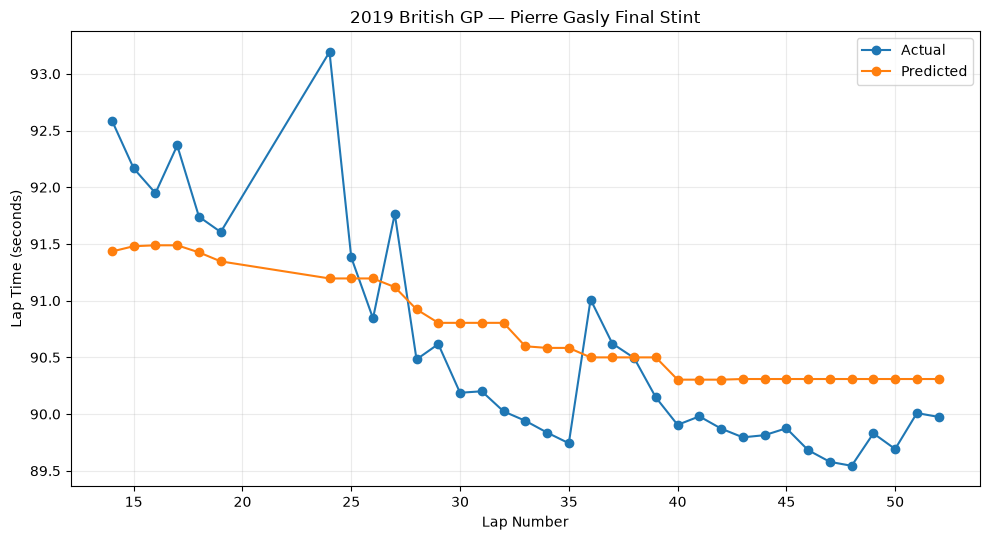

In [7]:
# Pick the driver with the longest final stint
plot_driver = test.groupby("driverId").size().idxmax()

plot_df = test[
    test["driverId"] == plot_driver
].sort_values("lapNumber").copy()

driver_mask = test["driverId"].eq(plot_driver).to_numpy()

plot_df["predicted_sec"] = predictions[
    ("Gradient Boosting", "Tire-age enhanced")
][driver_mask]

driver_name = race_results.loc[
    race_results["driverId"] == plot_driver,
    "driverName"
].iloc[0]

plt.figure(figsize=(10, 5.5))

plt.plot(
    plot_df["lapNumber"],
    plot_df["lap_time_sec"],
    marker="o",
    label="Actual"
)

plt.plot(
    plot_df["lapNumber"],
    plot_df["predicted_sec"],
    marker="o",
    label="Predicted"
)

plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title(
    f"2019 British GP — {driver_name} Final Stint"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Interpretation

In [8]:
pivot = comparison.pivot(
    index="Model",
    columns="Feature_Set",
    values=["RMSE_seconds", "MAE_seconds"]
)

display(pivot)

for model_name in comparison["Model"].unique():

    rows = comparison[
        comparison["Model"] == model_name
    ].set_index("Feature_Set")

    base_rmse = rows.loc["Baseline", "RMSE_seconds"]
    tire_rmse = rows.loc["Tire-age enhanced", "RMSE_seconds"]

    base_mae = rows.loc["Baseline", "MAE_seconds"]
    tire_mae = rows.loc["Tire-age enhanced", "MAE_seconds"]

    print(f"\n{model_name}")

    if tire_rmse < base_rmse:
        print("• Tire age improves RMSE.")
    else:
        print("• Tire age does not improve RMSE.")

    if tire_mae < base_mae:
        print("• Tire age improves MAE.")
    else:
        print("• Tire age does not improve MAE.")

print("\nLower RMSE and MAE indicate better prediction accuracy.")
print("The final-stint plot should be used to discuss whether predicted lap times follow the actual trend as tire age increases.")

RMSE_seconds                   MAE_seconds                  
Feature_Set           Baseline Tire-age enhanced    Baseline Tire-age enhanced
Model                                                                         
Gradient Boosting     0.764995          0.764911    0.583904          0.592170
Random Forest         0.868345          0.856891    0.552760          0.550185


Random Forest
• Tire age improves RMSE.
• Tire age improves MAE.

Gradient Boosting
• Tire age improves RMSE.
• Tire age does not improve MAE.

Lower RMSE and MAE indicate better prediction accuracy.
The final-stint plot should be used to discuss whether predicted lap times follow the actual trend as tire age increases.


In [9]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

clean.to_csv(
    "cleaned_lap_data.csv",
    index=False
)

print("Saved: model_comparison.csv")
print("Saved: cleaned_lap_data.csv")

Saved: model_comparison.csv
Saved: cleaned_lap_data.csv
